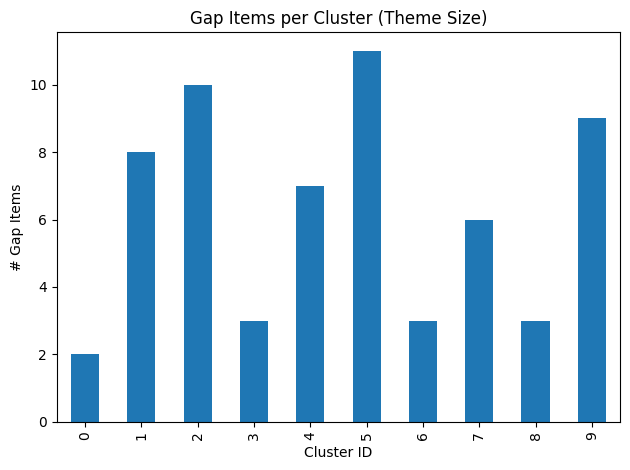

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

gaps = pd.read_csv("../artifacts/gaps_with_clusters.tsv", sep="\t")

counts = gaps[gaps["cluster_id"] != -1]["cluster_id"].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")
plt.title("Gap Items per Cluster (Theme Size)")
plt.xlabel("Cluster ID")
plt.ylabel("# Gap Items")
plt.tight_layout()
plt.savefig("cluster_sizes.png", dpi=200)
plt.show()


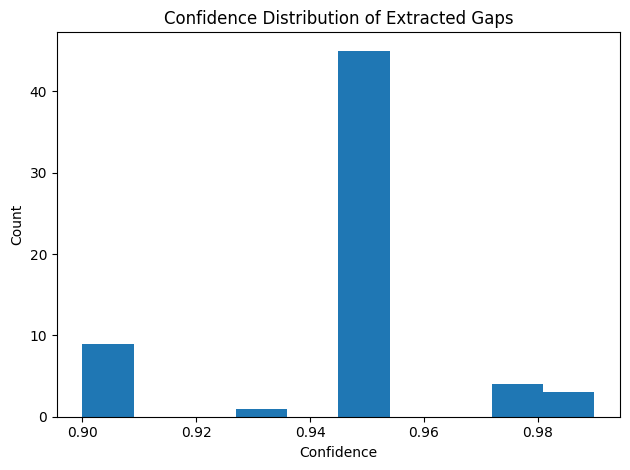

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

gaps = pd.read_csv("../data/gaps_openai.tsv", sep="\t")

plt.figure()
plt.hist(gaps["confidence"].dropna(), bins=10)
plt.title("Confidence Distribution of Extracted Gaps")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("confidence_hist.png", dpi=200)
plt.show()


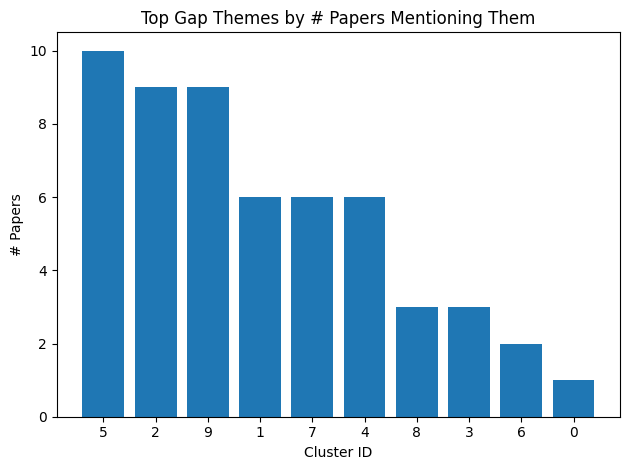

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

gaps = pd.read_csv("../artifacts/gaps_with_clusters.tsv", sep="\t")

theme_strength = (
    gaps[gaps["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(n_papers=("id", "nunique"), n_items=("gap_sentence", "count"))
    .sort_values("n_papers", ascending=False)
    .head(10)
)

plt.figure()
plt.bar(theme_strength.index.astype(str), theme_strength["n_papers"])
plt.title("Top Gap Themes by # Papers Mentioning Them")
plt.xlabel("Cluster ID")
plt.ylabel("# Papers")
plt.tight_layout()
plt.savefig("top_gap_themes_by_papers.png", dpi=200)
plt.show()


In [4]:
!pip -q install umap-learn


c:\Users\yazan\OneDrive\Desktop\thesis\Gap2Idea\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\yazan\OneDrive\Desktop\thesis\Gap2Idea\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


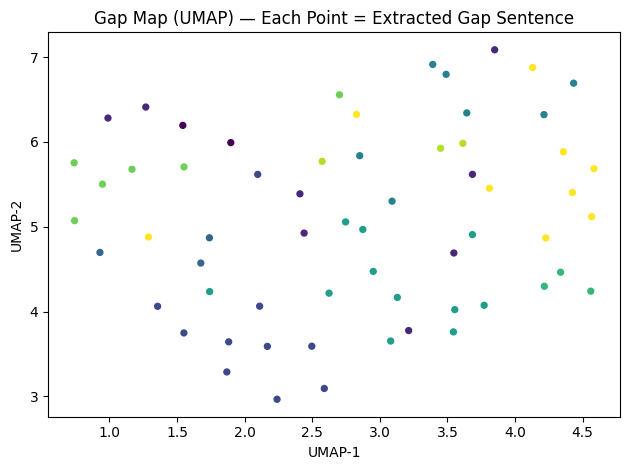

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap

gaps = pd.read_csv("../artifacts/gaps_with_clusters.tsv", sep="\t")
X = np.load("../artifacts/gap_embeddings.npy")

mask = gaps["cluster_id"] != -1
gaps2 = gaps[mask].reset_index(drop=True)
X2 = X[mask.values]

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z = reducer.fit_transform(X2)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=gaps2["cluster_id"], s=18)
plt.title("Gap Map (UMAP) — Each Point = Extracted Gap Sentence")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("gap_umap_map.png", dpi=200)
plt.show()


In [6]:
!pip -q install networkx


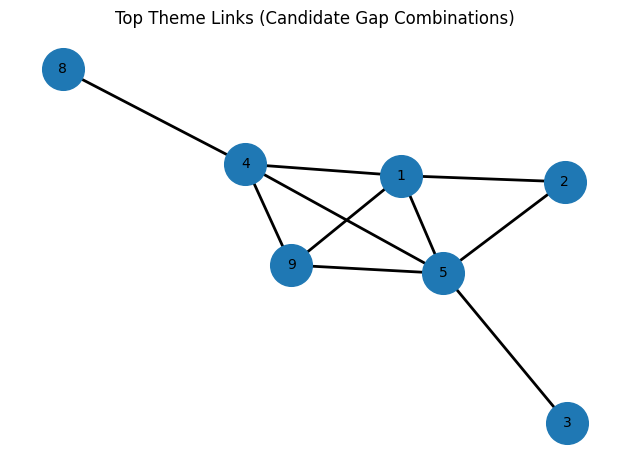

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pairs = pd.read_csv("../artifacts/cluster_pairs.tsv", sep="\t")
top = pairs.sort_values("cosine_sim", ascending=False).head(10)

G = nx.Graph()
for _, r in top.iterrows():
    a, b = int(r["cluster_a"]), int(r["cluster_b"])
    w = float(r["cosine_sim"])
    G.add_edge(a, b, weight=w)

plt.figure()
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=2)

plt.title("Top Theme Links (Candidate Gap Combinations)")
plt.axis("off")
plt.tight_layout()
plt.savefig("theme_links_graph.png", dpi=200)
plt.show()


In [8]:
!pip -q install wordcloud


Top cluster: 5


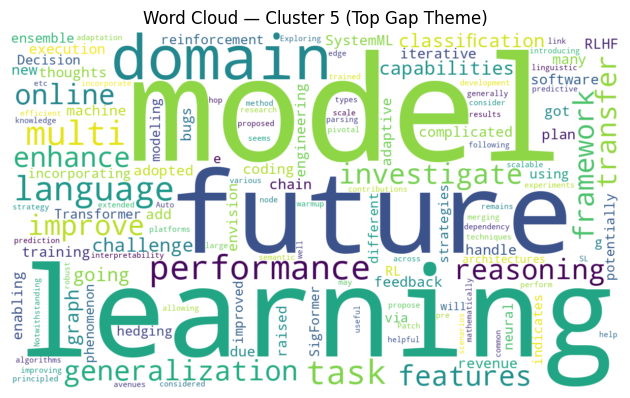

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

gaps = pd.read_csv("../artifacts/gaps_with_clusters.tsv", sep="\t")

# Pick the strongest cluster = most papers mentioning it
cluster_rank = (
    gaps[gaps["cluster_id"] != -1]
    .groupby("cluster_id")["id"]
    .nunique()
    .sort_values(ascending=False)
)

top_cluster = int(cluster_rank.index[0])
print("Top cluster:", top_cluster)

text = " ".join(
    gaps[gaps["cluster_id"] == top_cluster]["gap_sentence"].astype(str).tolist()
)

wc = WordCloud(width=1200, height=700, background_color="white").generate(text)

plt.figure()
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud — Cluster {top_cluster} (Top Gap Theme)")
plt.tight_layout()
plt.savefig("wordcloud_top_cluster.png", dpi=200)
plt.show()


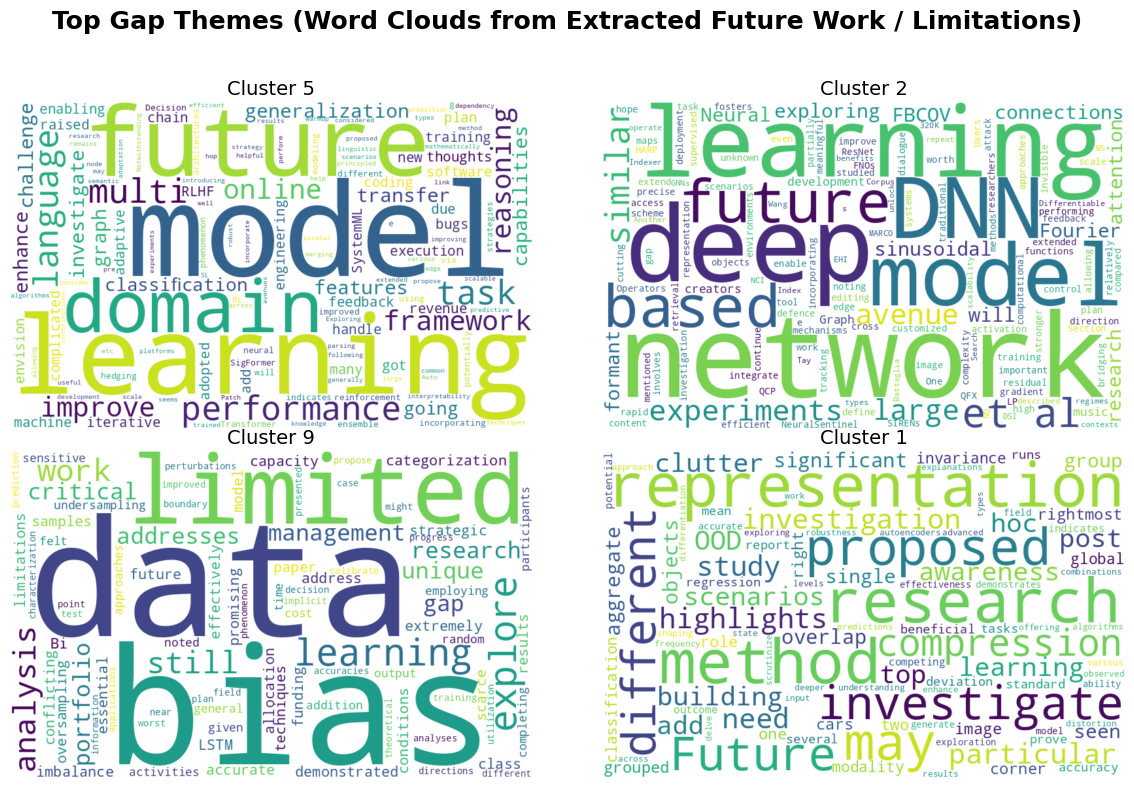

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

gaps = pd.read_csv("../artifacts/gaps_with_clusters.tsv", sep="\t")

top_clusters = (
    gaps[gaps["cluster_id"] != -1]
    .groupby("cluster_id")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

fig = plt.figure(figsize=(12, 8))

for i, cid in enumerate(top_clusters, 1):
    text = " ".join(gaps[gaps["cluster_id"] == cid]["gap_sentence"].astype(str).tolist())
    wc = WordCloud(width=800, height=500, background_color="white").generate(text)

    ax = fig.add_subplot(2, 2, i)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Cluster {cid}", fontsize=14)

# Main title for the full figure
fig.suptitle("Top Gap Themes (Word Clouds from Extracted Future Work / Limitations)", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the main title
plt.savefig("wordcloud_top4_clusters.png", dpi=200)
plt.show()
